In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [47]:
df = pd.read_csv(r"C:\Users\admin\Documents\machine-learning-code-orbit\team_members\From_Arooba\Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [48]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [49]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [50]:
# Convert categorical text data into numerical format
le = LabelEncoder()  # code to convert categorical text data into numerical format
df["Gender"] = le.fit_transform(df["Gender"])  # Convert Male/Femal into numerical format

X = df[["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
# Perform PCA to reduce dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

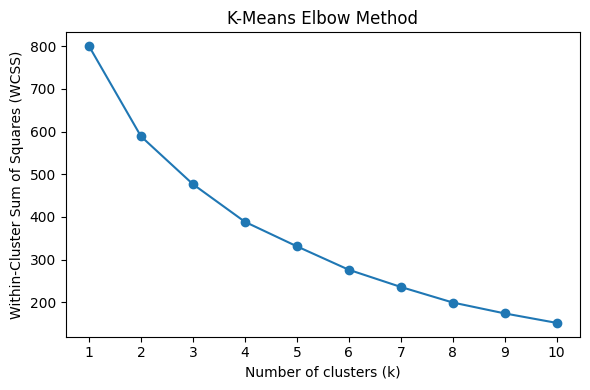

In [52]:
# Pick the number of clusters using the Elbow Method (K-Means WCSS)

wcss = []  # within-cluster sum of squares (inertia)
K_RANGE = range(1, 11)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(K_RANGE), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("K-Means Elbow Method")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

In [53]:
# Run K-Means with a chosen k (commonly 5 for this dataset, but inspect the elbow)

K_SELECTED = 5  # change if the elbow suggests another value
kmeans = KMeans(n_clusters=K_SELECTED, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

In [54]:
# Run Hierarchical (Agglomerative) Clustering

# We'll use Ward linkage (the default for AgglomerativeClustering when affinity='euclidean').
HC_CLUSTERS = 5  # match k for easy comparison; feel free to tune
hc = AgglomerativeClustering(n_clusters=HC_CLUSTERS, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)


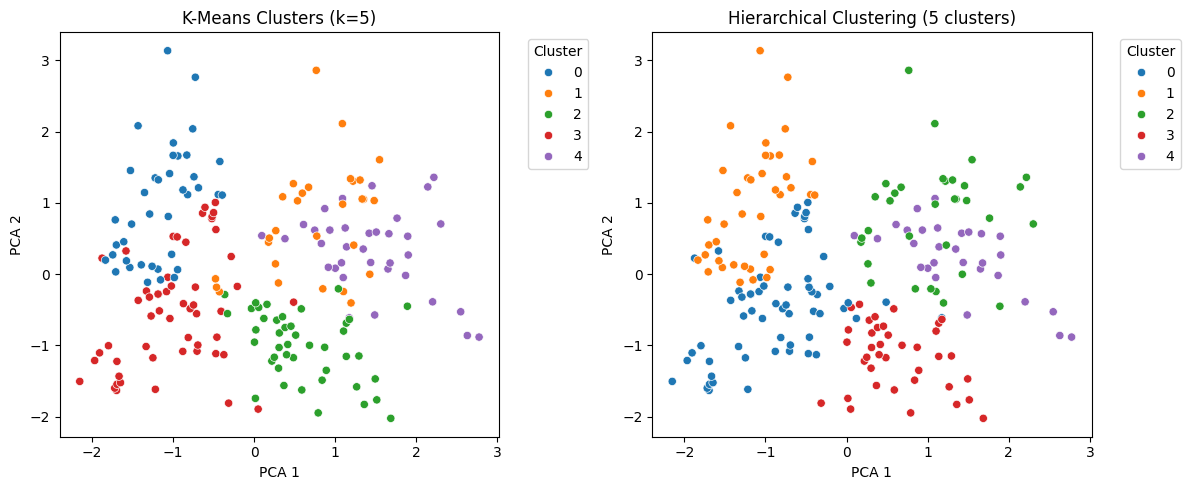

In [55]:
# Visualize clusters in PCA-reduced 2D space

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# K-Means scatter
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_km, palette="tab10", ax=axs[0])
axs[0].set_title(f"K-Means Clusters (k={K_SELECTED})")
axs[0].set_xlabel("PCA 1")
axs[0].set_ylabel("PCA 2")
axs[0].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# Hierarchical scatter
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_hc, palette="tab10", ax=axs[1])
axs[1].set_title(f"Hierarchical Clustering ({HC_CLUSTERS} clusters)")
axs[1].set_xlabel("PCA 1")
axs[1].set_ylabel("PCA 2")
axs[1].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

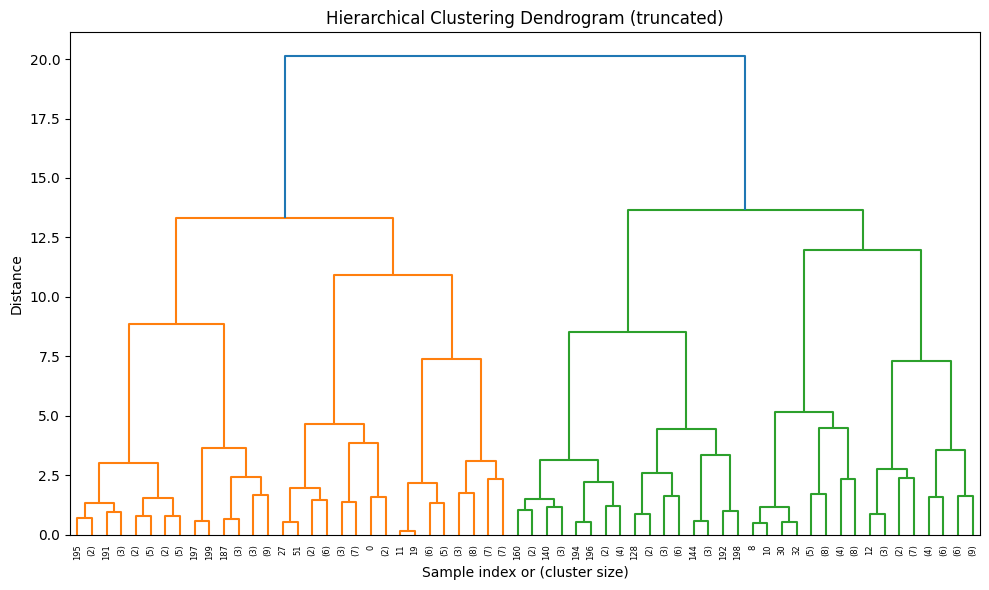

In [56]:
# Hierarchical clustering dendrogram

# Building the linkage matrix separately for a dendrogram. For large datasets this can be expensive.
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)  # truncate for readability
plt.title("Hierarchical Clustering Dendrogram (truncated)")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [57]:
#  Attach cluster labels to the DataFrame and summarize

df["Cluster_KM"] = labels_km
df["Cluster_HC"] = labels_hc

# Summary statistics for K-Means clusters
summary_km = df.groupby("Cluster_KM")['CustomerID'].agg(['mean', 'median', 'min', 'max', 'count'])
print("\n=== K-Means Cluster Summary ===")
print(summary_km)

# Summary statistics for Hierarchical clusters
summary_hc = df.groupby("Cluster_HC")['CustomerID'].agg(['mean', 'median', 'min', 'max', 'count'])
print("\n=== Hierarchical Cluster Summary ===")
print(summary_hc)




=== K-Means Cluster Summary ===
                  mean  median  min  max  count
Cluster_KM                                     
0           162.000000   162.0  124  200     39
1           165.482759   167.0  125  199     29
2            73.651163    73.0    7  161     43
3            52.814815    47.0    1  121     54
4            84.685714    82.0    9  179     35

=== Hierarchical Cluster Summary ===
                  mean  median  min  max  count
Cluster_HC                                     
0            62.409836    53.0    1  143     61
1           162.000000   162.0  124  200     39
2           166.090909   167.0  129  199     33
3            61.210526    63.5    3  120     38
4            74.758621    78.0    9  147     29



=== K-Means Cluster Centers (Original Scale) ===
         Gender        Age  Annual Income (k$)  Spending Score (1-100)
0  4.615385e-01  32.692308           86.538462               82.128205
1  4.482759e-01  36.482759           89.517241               18.000000
2 -5.551115e-17  49.813953           49.232558               40.069767
3  4.074074e-01  24.907407           39.722222               61.203704
4  1.000000e+00  55.714286           53.685714               36.771429


<Figure size 800x500 with 0 Axes>

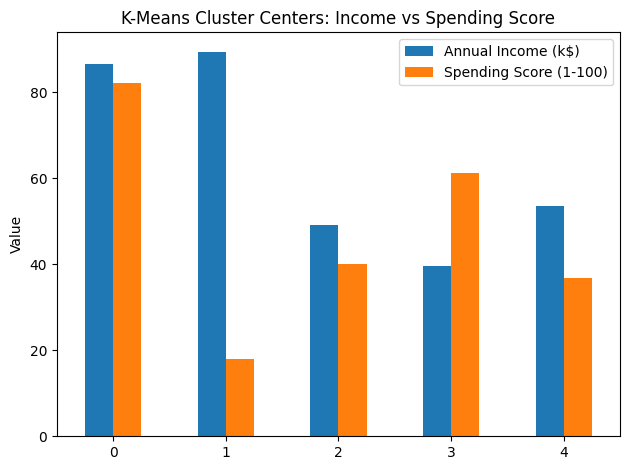

In [ ]:
# Define the feature columns (must match the columns used during scaling)
FEATURE_COLS = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

# Inverse-transform the scaled cluster centers to the original feature scale
centers_scaled = kmeans.cluster_centers_
centers_orig = scaler.inverse_transform(centers_scaled)

# Create a DataFrame for better readability
centers_df = pd.DataFrame(centers_orig, columns=FEATURE_COLS)

# Print the original-scale cluster centers
print("\n=== K-Means Cluster Centers (Original Scale) ===")
print(centers_df)

# Bar plot of K-Means cluster centers for Annual Income & Spending Score
plt.figure(figsize=(8, 5))
centers_plot = centers_df[["Annual Income (k$)", "Spending Score (1-100)"]]
centers_plot.plot(kind='bar')
plt.title("K-Means Cluster Centers: Income vs Spending Score")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [59]:
# Save enriched dataset (with cluster labels) to CSV

OUTPUT_PATH = "Mall_Customers_with_clusters.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"\nFile saved with cluster labels: {OUTPUT_PATH}")



File saved with cluster labels: Mall_Customers_with_clusters.csv
